In [5]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, "/home/hpc/iwi5/iwi5437h/ct-anomaly-detection")
from src.ct_anomaly.data.segmentation import combine_lung_masks, get_bounding_box

In [6]:
sys.path.insert(0, "/home/hpc/iwi5/iwi5437h/ct-anomaly-detection")

DATA_PATH = Path("/anvme/workspace/b180dc29-CT_RATE_IDEA_MIRROR")
MASKS_PATH = Path("/anvme/workspace/iwi5437h-ct-anomaly-detection/lung_masks")
HOME_MASKS = Path("/home/hpc/iwi5/iwi5437h/ct-anomaly-detection/data/processed/lung_masks")

VOLUMES = [
    {"volume_name": "valid_375_a_1",   "patient_id": "valid_375",   "scan_id": "a", "split": "valid"},
    {"volume_name": "train_6167_a_1",  "patient_id": "train_6167",  "scan_id": "a", "split": "train"},
    {"volume_name": "train_4111_a_1",  "patient_id": "train_4111",  "scan_id": "a", "split": "train"},
    {"volume_name": "train_19305_a_1", "patient_id": "train_19305", "scan_id": "a", "split": "train"},
    {"volume_name": "train_16902_a_1", "patient_id": "train_16902", "scan_id": "a", "split": "train"},
]

In [7]:
def get_mask_dir(volume_name):
    anvme = MASKS_PATH / volume_name

    # Check if the directory exists and contains the expected files
    if anvme.exists():
        files = list(anvme.glob("*.nii.gz"))
        if len(files) == 5 and all(f.stat().st_size > 0 for f in files):
            return anvme
    return HOME_MASKS / volume_name

valid_375_a_1: bbox={'x_min': 52, 'x_max': 702, 'y_min': 134, 'y_max': 647, 'z_min': 0, 'z_max': 168}
train_6167_a_1: bbox={'x_min': 49, 'x_max': 472, 'y_min': 58, 'y_max': 363, 'z_min': 22, 'z_max': 220}
train_4111_a_1: bbox={'x_min': 171, 'x_max': 920, 'y_min': 271, 'y_max': 799, 'z_min': 68, 'z_max': 218}
train_19305_a_1: bbox={'x_min': 44, 'x_max': 471, 'y_min': 88, 'y_max': 390, 'z_min': 8, 'z_max': 194}
train_16902_a_1: bbox={'x_min': 60, 'x_max': 452, 'y_min': 44, 'y_max': 361, 'z_min': 50, 'z_max': 231}


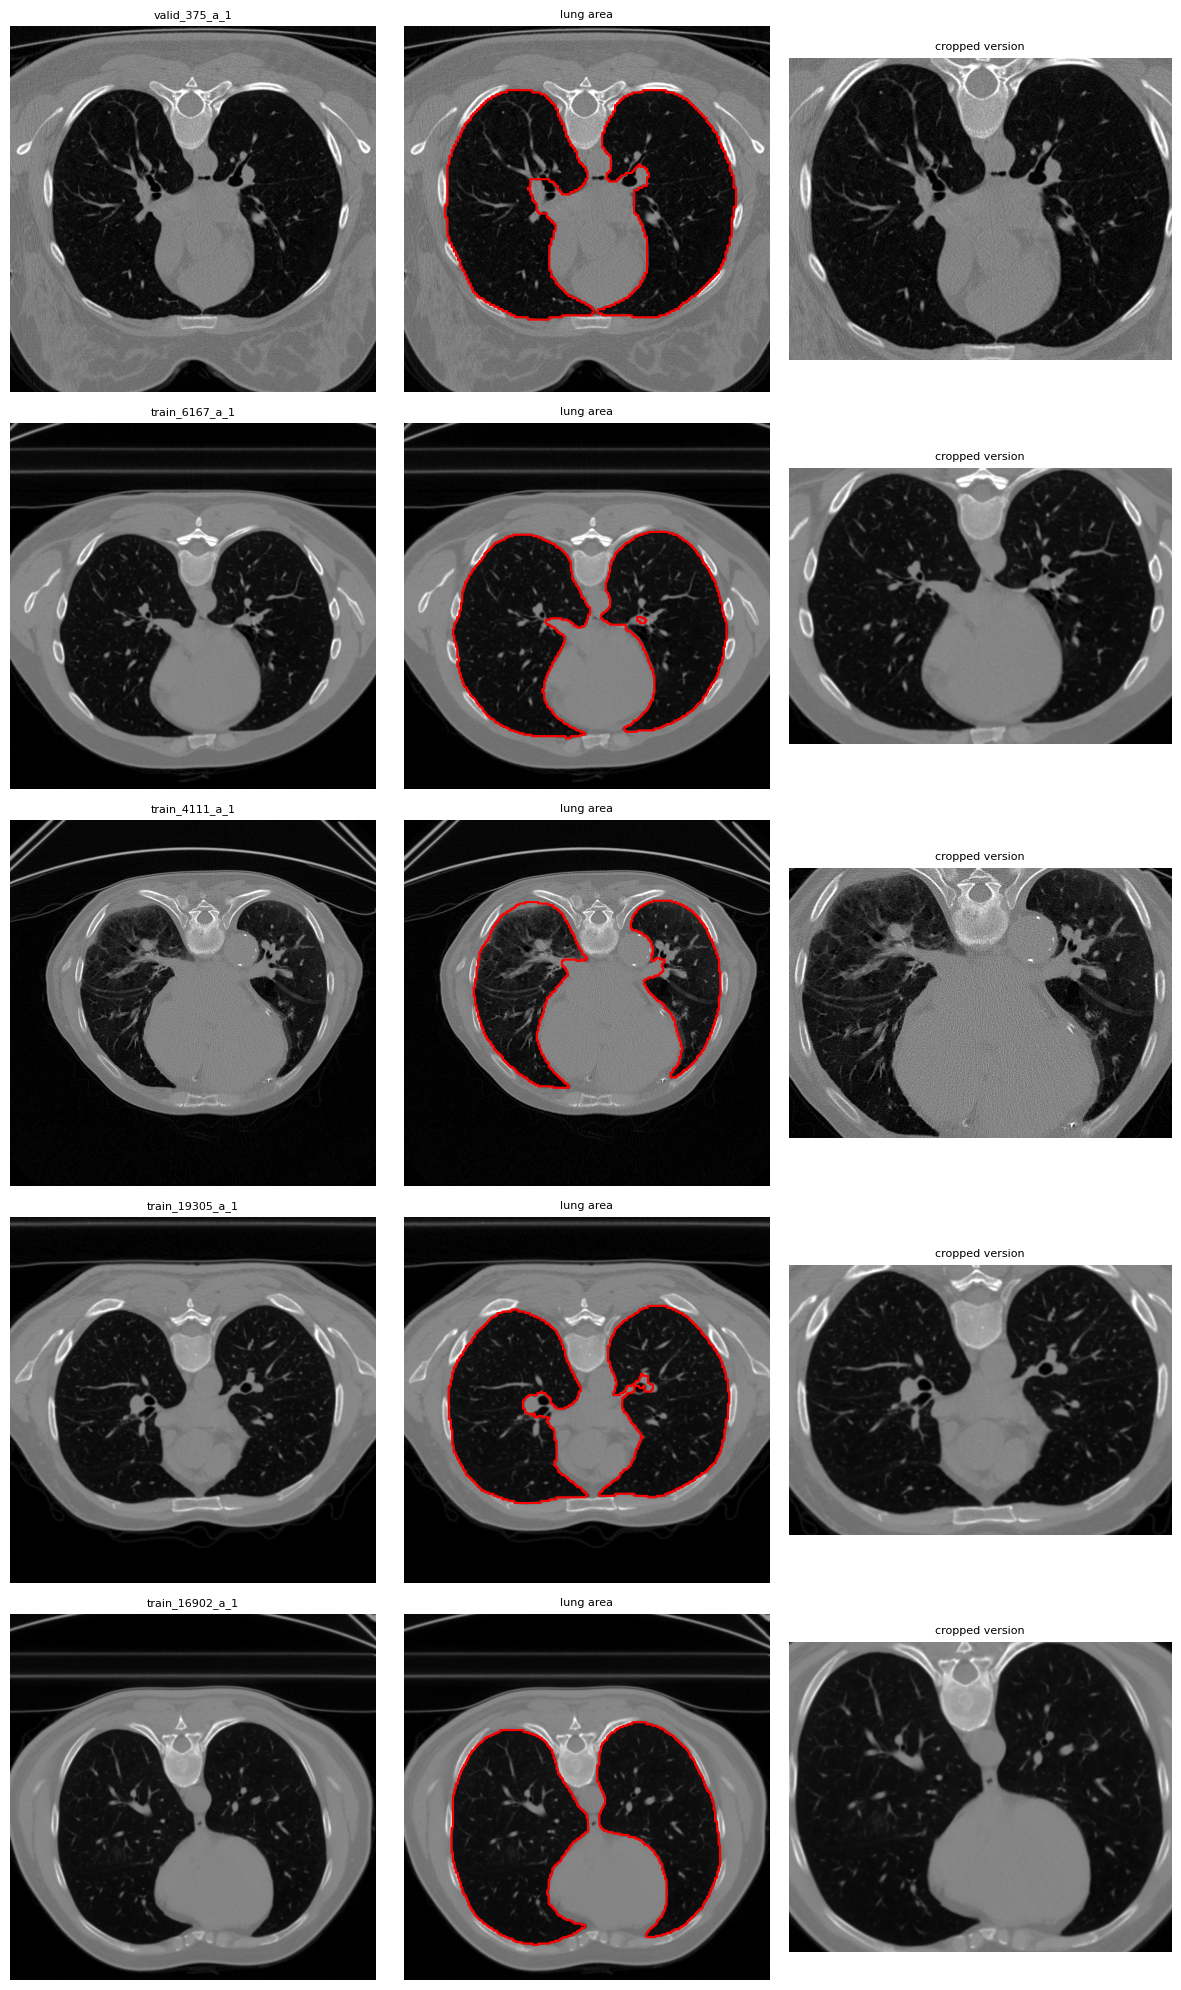

In [8]:
fig, axes = plt.subplots(5, 3, figsize=(12, 20))

for i, vol in enumerate(VOLUMES):
    volume_name = vol["volume_name"]
    mask_dir = get_mask_dir(volume_name)

    # Load CT volume and get middle slice
    vol_path = DATA_PATH / f"CT-RATE_{vol['split']}_fixed" / vol["patient_id"] / f"{vol['patient_id']}_{vol['scan_id']}" / f"{volume_name}.nii.gz"
    nii = nib.load(vol_path)
    shape = nii.shape
    middle_depth = shape[2] // 2

    # Load CT slice and clip values
    data_proxy = nii.dataobj
    ct_slice = np.array(data_proxy[:, :, middle_depth]).astype(np.float32)
    ct_slice = np.clip(ct_slice, -1000, 1000)

    # Load mask
    lung_mask = combine_lung_masks(mask_dir)
    mask_slice = lung_mask[:, :, middle_depth]
    bbox = get_bounding_box(lung_mask)

    # Cropped CT slice
    cropped = ct_slice[bbox["x_min"]:bbox["x_max"], bbox["y_min"]:bbox["y_max"]]

    # Plot
    axes[i, 0].imshow(ct_slice.T, cmap="gray", origin="lower")
    axes[i, 0].set_title(volume_name, fontsize=8)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(ct_slice.T, cmap="gray", origin="lower")
    axes[i, 1].contour(mask_slice.T, levels=[0.5], colors=["red"], linewidths=[1.5])
    axes[i, 1].set_title("lung area", fontsize=8)
    axes[i, 1].axis("off")

    axes[i, 2].imshow(cropped.T, cmap="gray", origin="lower")
    axes[i, 2].set_title(f"cropped version", fontsize=8)
    axes[i, 2].axis("off")

    print(f"{volume_name}: bbox={bbox}")

plt.tight_layout()
plt.savefig("/home/hpc/iwi5/iwi5437h/ct-anomaly-detection/analysis/segmentation_check.png", dpi=150)
plt.show()